In [1]:
## Statistical Analysis - Part 2Pairwise group comparisons using t-tests and Fisher's exact test.Q
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, fisher_exact, false_discovery_control

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load cleaned dataset
df = pd.read_csv('data/marketing_data.csv', parse_dates=['Date'])

print(f"Dataset loaded: {df.shape}")
print(f"Channels: {df['Campaign_Type'].unique().tolist()}")

Dataset loaded: (166665, 23)
Channels: ['Social Media', 'Paid Ads', 'Influencer', 'Email', 'SEO']


In [2]:
## Step 4: Pairwise t-tests - Compare CPA, ROAS and Conversion Rate between all channel pairs.
#Includes effect size (Cohen's d) to assess practical significance.
# Metrics to compare
metrics = ['CPA', 'ROAS', 'Conv_Rate']

# Store all results
all_results = []

for metric in metrics:
    print(f"\n{'='*60}")
    print(f"METRIC: {metric}")
    print(f"{'='*60}")
    
    # Prepare clean data for this metric
    clean = df[['Campaign_Type', metric]].dropna()
    clean = clean[~np.isinf(clean[metric])]
    
    # Get unique groups
    groups = clean['Campaign_Type'].unique()
    
    # Compare every unique pair
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            group_a = groups[i]
            group_b = groups[j]
            
            # Extract values
            values_a = clean[clean['Campaign_Type'] == group_a][metric].values
            values_b = clean[clean['Campaign_Type'] == group_b][metric].values
            
            # t-test
            t_stat, p_value = ttest_ind(values_a, values_b)
            
            # Means and difference
            mean_a = values_a.mean()
            mean_b = values_b.mean()
            difference = mean_b - mean_a
            pct_diff = (difference / mean_a) * 100
            
            # Cohen's d
            pooled_std = np.sqrt((np.var(values_a) + np.var(values_b)) / 2)
            cohens_d = difference / pooled_std if pooled_std > 0 else 0
            
            # Effect size interpretation
            abs_d = abs(cohens_d)
            if abs_d < 0.2:
                effect_size = 'negligible'
            elif abs_d < 0.5:
                effect_size = 'small'
            elif abs_d < 0.8:
                effect_size = 'medium'
            else:
                effect_size = 'large'
            
            # Significance flag
            significant = p_value < 0.05
            
            # Store result
            all_results.append({
                'Metric'     : metric,
                'Group_A'    : group_a,
                'Group_B'    : group_b,
                'Mean_A'     : round(mean_a, 4),
                'Mean_B'     : round(mean_b, 4),
                'Difference' : round(difference, 4),
                'Pct_Diff'   : round(pct_diff, 2),
                'T_Stat'     : round(t_stat, 4),
                'P_Value'    : round(p_value, 4),
                'Cohens_d'   : round(cohens_d, 4),
                'Effect_Size': effect_size,
                'Significant': significant
            })
            
            # Print result
            sig_marker = '*** SIGNIFICANT ***' if significant else 'not significant'
            print(f"\n  {group_a} vs {group_b}")
            print(f"    Mean A: {mean_a:.4f}  Mean B: {mean_b:.4f}")
            print(f"    Difference: {difference:.4f} ({pct_diff:.2f}%)")
            print(f"    t={t_stat:.4f}  p={p_value:.4f}  {sig_marker}")
            print(f"    Cohen's d={cohens_d:.4f}  Effect: {effect_size}")

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

# Summary
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Total comparisons : {len(results_df)}")
print(f"Significant (p<0.05): {results_df['Significant'].sum()}")
print(f"\nBy metric:")
print(results_df.groupby('Metric')['Significant'].sum())


METRIC: CPA

  Social Media vs Paid Ads
    Mean A: 2.0539  Mean B: 2.0244
    Difference: -0.0295 (-1.44%)
    t=0.3719  p=0.7100  not significant
    Cohen's d=-0.0029  Effect: negligible

  Social Media vs Influencer
    Mean A: 2.0539  Mean B: 2.1048
    Difference: 0.0508 (2.47%)
    t=-0.6502  p=0.5156  not significant
    Cohen's d=0.0050  Effect: negligible

  Social Media vs Email
    Mean A: 2.0539  Mean B: 2.1110
    Difference: 0.0571 (2.78%)
    t=-0.6937  p=0.4878  not significant
    Cohen's d=0.0054  Effect: negligible

  Social Media vs SEO
    Mean A: 2.0539  Mean B: 2.0863
    Difference: 0.0324 (1.58%)
    t=-0.4363  p=0.6626  not significant
    Cohen's d=0.0034  Effect: negligible

  Paid Ads vs Influencer
    Mean A: 2.0244  Mean B: 2.1048
    Difference: 0.0803 (3.97%)
    t=-0.9836  p=0.3253  not significant
    Cohen's d=0.0076  Effect: negligible

  Paid Ads vs Email
    Mean A: 2.0244  Mean B: 2.1110
    Difference: 0.0866 (4.28%)
    t=-1.0114  p=0.3118  n

## t-test Results Summary
Zero significant differences found across all 30 pairwise comparisons.
All Cohen's d values are negligible (< 0.02), indicating no practically
meaningful differences between channels at the individual campaign level.

In [3]:
# Display full results table
print("FULL RESULTS TABLE:")
results_df

FULL RESULTS TABLE:


,Metric,Group_A,Group_B,Mean_A,Mean_B,Difference,Pct_Diff,T_Stat,P_Value,Cohens_d,Effect_Size,Significant
0,CPA,Social Media,Paid Ads,2.0539,2.0244,-0.0295,-1.44,0.3719,0.7100,-0.0029,negligible,False
1,CPA,Social Media,Influencer,2.0539,2.1048,0.0508,2.47,-0.6502,0.5156,0.0050,negligible,False
2,CPA,Social Media,Email,2.0539,2.1110,0.0571,2.78,-0.6937,0.4878,0.0054,negligible,False
3,CPA,Social Media,SEO,2.0539,2.0863,0.0324,1.58,-0.4363,0.6626,0.0034,negligible,False
4,CPA,Paid Ads,Influencer,2.0244,2.1048,0.0803,3.97,-0.9836,0.3253,0.0076,negligible,False
5,CPA,Paid Ads,Email,2.0244,2.1110,0.0866,4.28,-1.0114,0.3118,0.0078,negligible,False
6,CPA,Paid Ads,SEO,2.0244,2.0863,0.0619,3.06,-0.7940,0.4272,0.0062,negligible,False
7,CPA,Influencer,Email,2.1048,2.1110,0.0063,0.30,-0.0744,0.9407,0.0006,negligible,False
8,CPA,Influencer,SEO,2.1048,2.0863,-0.0184,-0.88,0.2402,0.8102,-0.0019,negligible,False
9,CPA,Email,SEO,2.1110,2.0863,-0.0247,-1.17,0.3053,0.7602,-0.0024,negligible,False


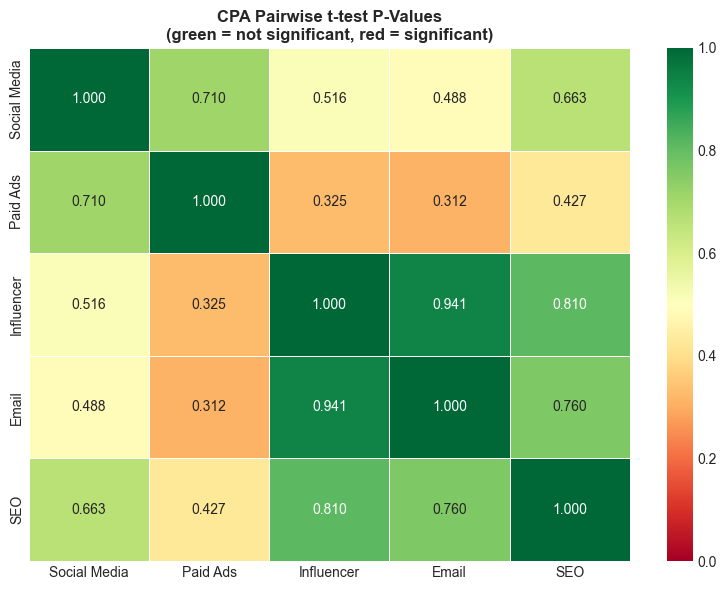

✓ Saved: cpa_comparison_heatmap.png


In [4]:
## P-Value Heatmap - Visual representation of pairwise t-test p-values for CPA.
# Build p-value matrix for CPA
channels = df['Campaign_Type'].unique()
n = len(channels)

# Create square matrix filled with 1.0
pvalue_matrix = pd.DataFrame(
    np.ones((n, n)), 
    index=channels, 
    columns=channels
)

# Fill matrix with p-values from CPA comparisons
cpa_results = results_df[results_df['Metric'] == 'CPA']
for _, row in cpa_results.iterrows():
    pvalue_matrix.loc[row['Group_A'], row['Group_B']] = row['P_Value']
    pvalue_matrix.loc[row['Group_B'], row['Group_A']] = row['P_Value']

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pvalue_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title('CPA Pairwise t-test P-Values\n(green = not significant, red = significant)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cpa_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: cpa_comparison_heatmap.png")

## Fisher's Exact Test - Pairwise Conversion Rate Comparisons - Binary outcome comparison: did a click convert or not?
#Tests whether conversion rates differ significantly across channel pairs.

In [5]:
# Aggregate conversions and clicks by channel
binary = df.groupby('Campaign_Type').agg(
    Conversions  = ('Conversions', 'sum'),
    Clicks       = ('Clicks', 'sum')
).reset_index()

binary['Non_Conversions'] = binary['Clicks'] - binary['Conversions']
binary['Conv_Rate']       = (binary['Conversions'] / binary['Clicks']).round(4)

print("CONVERSION SUMMARY BY CHANNEL:")
print(binary.to_string(index=False))

CONVERSION SUMMARY BY CHANNEL:
Campaign_Type  Conversions    Clicks  Non_Conversions  Conv_Rate
        Email     34472617 156471621        121999004     0.2203
   Influencer     34330330 156531226        122200896     0.2193
     Paid Ads     34351331 156264327        121912996     0.2198
          SEO     34026853 154817943        120791090     0.2198
 Social Media     34331968 156301670        121969702     0.2197


In [6]:
# Store Fisher's test results
fisher_results = []

channels = binary['Campaign_Type'].unique()

for i in range(len(channels)):
    for j in range(i+1, len(channels)):
        channel_a = channels[i]
        channel_b = channels[j]
        
        # Get counts for each channel
        row_a = binary[binary['Campaign_Type'] == channel_a].iloc[0]
        row_b = binary[binary['Campaign_Type'] == channel_b].iloc[0]
        
        # Build 2x2 contingency table
        contingency = [
            [row_a['Conversions'], row_a['Non_Conversions']],
            [row_b['Conversions'], row_b['Non_Conversions']]
        ]
        
        # Fisher's exact test
        odds_ratio, p_value = fisher_exact(contingency, alternative='two-sided')
        
        # Rates
        rate_a = row_a['Conv_Rate']
        rate_b = row_b['Conv_Rate']
        difference = rate_b - rate_a
        pct_diff = (difference / rate_a) * 100
        
        # Significance flag
        significant = p_value < 0.05
        
        # Store result
        fisher_results.append({
            'Channel_A'      : channel_a,
            'Channel_B'      : channel_b,
            'Conversions_A'  : row_a['Conversions'],
            'Conversions_B'  : row_b['Conversions'],
            'Clicks_A'       : row_a['Clicks'],
            'Clicks_B'       : row_b['Clicks'],
            'Rate_A'         : rate_a,
            'Rate_B'         : rate_b,
            'Difference'     : round(difference, 6),
            'Pct_Diff'       : round(pct_diff, 4),
            'Odds_Ratio'     : round(odds_ratio, 4),
            'P_Value'        : round(p_value, 4),
            'Significant'    : significant
        })
        
        # Print result
        sig_marker = '*** SIGNIFICANT ***' if significant else 'not significant'
        print(f"\n  {channel_a} vs {channel_b}")
        print(f"    Rate A: {rate_a:.4f}  Rate B: {rate_b:.4f}")
        print(f"    Difference: {difference:.6f} ({pct_diff:.4f}%)")
        print(f"    Odds Ratio: {odds_ratio:.4f}  p={p_value:.4f}  {sig_marker}")

# Convert to DataFrame
fisher_df = pd.DataFrame(fisher_results)

# Summary
print(f"\n{'='*60}")
print(f"FISHER'S EXACT TEST SUMMARY")
print(f"{'='*60}")
print(f"Total comparisons    : {len(fisher_df)}")
print(f"Significant (p<0.05) : {fisher_df['Significant'].sum()}")


  Email vs Influencer
    Rate A: 0.2203  Rate B: 0.2193
    Difference: -0.001000 (-0.4539%)
    Odds Ratio: 1.0058  p=0.0000  *** SIGNIFICANT ***

  Email vs Paid Ads
    Rate A: 0.2203  Rate B: 0.2198
    Difference: -0.000500 (-0.2270%)
    Odds Ratio: 1.0028  p=0.0000  *** SIGNIFICANT ***

  Email vs SEO
    Rate A: 0.2203  Rate B: 0.2198
    Difference: -0.000500 (-0.2270%)
    Odds Ratio: 1.0031  p=0.0000  *** SIGNIFICANT ***

  Email vs Social Media
    Rate A: 0.2203  Rate B: 0.2197
    Difference: -0.000600 (-0.2724%)
    Odds Ratio: 1.0039  p=0.0000  *** SIGNIFICANT ***

  Influencer vs Paid Ads
    Rate A: 0.2193  Rate B: 0.2198
    Difference: 0.000500 (0.2280%)
    Odds Ratio: 0.9970  p=0.0000  *** SIGNIFICANT ***

  Influencer vs SEO
    Rate A: 0.2193  Rate B: 0.2198
    Difference: 0.000500 (0.2280%)
    Odds Ratio: 0.9973  p=0.0000  *** SIGNIFICANT ***

  Influencer vs Social Media
    Rate A: 0.2193  Rate B: 0.2197
    Difference: 0.000400 (0.1824%)
    Odds Ratio: 

## Key Insight: Statistical vs Practical Significance
Fisher's test finds 9/10 pairs significant (p=0.0000) due to massive 
sample sizes (150M+ clicks per channel). However odds ratios of 1.003-1.006 
indicate negligible practical differences. With N=150M, even a 0.05% 
difference becomes statistically detectable. Multiple comparisons correction 
and effect sizes are essential to avoid misleading budget decisions.

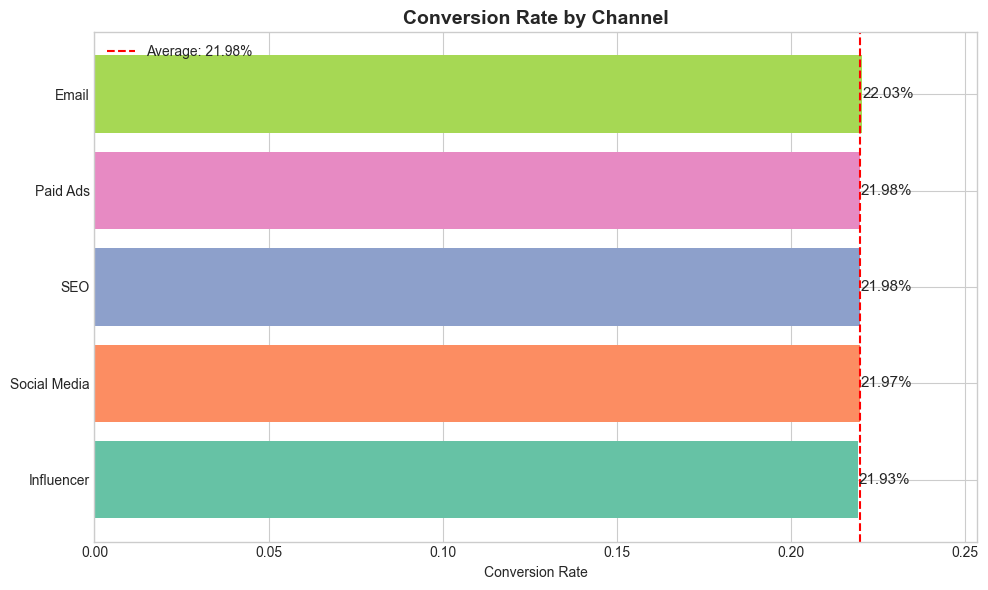

✓ Saved: rate_comparison.png


In [7]:
## Conversion Rate Comparison Chart - Horizontal bar chart comparing conversion rates across all channels.
# Sort by conversion rate
binary_sorted = binary.sort_values('Conv_Rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    binary_sorted['Campaign_Type'], 
    binary_sorted['Conv_Rate'],
    color=sns.color_palette("Set2", len(binary_sorted))
)

# Add value labels on bars
for bar, rate in zip(bars, binary_sorted['Conv_Rate']):
    ax.text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height()/2,
        f'{rate*100:.2f}%',
        va='center',
        fontsize=11
    )

ax.set_title('Conversion Rate by Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Conversion Rate')
ax.set_xlim(0, binary_sorted['Conv_Rate'].max() * 1.15)
ax.axvline(x=binary_sorted['Conv_Rate'].mean(), 
           color='red', linestyle='--', linewidth=1.5, 
           label=f"Average: {binary_sorted['Conv_Rate'].mean()*100:.2f}%")
ax.legend()

plt.tight_layout()
plt.savefig('rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: rate_comparison.png")

## Observation
The bar chart visually confirms negligible differences between channels.
Despite Fisher's test flagging 9/10 pairs as statistically significant (p=0.0000),
the chart reveals conversion rates cluster tightly between 21.93% and 22.03% —
a range of just 0.10%. This reinforces that statistical significance alone
is insufficient for budget allocation decisions. Effect size and practical
significance must always be considered alongside p-values.

In [8]:
## Part 3: Multiple Comparisons Correction - With 40 total comparisons at α=0.05, we expect 2 false positives by chance.
#Applying Bonferroni and Benjamini-Hochberg corrections to control false discovery rates.
# Count total comparisons
n_cpa        = len(results_df[results_df['Metric'] == 'CPA'])
n_fisher     = len(fisher_df)
n_total      = len(results_df) + n_fisher

print("MULTIPLE COMPARISONS PROBLEM")
print("="*60)
print(f"  t-test comparisons  (CPA, ROAS, Conv_Rate) : {len(results_df)}")
print(f"  Fisher's comparisons (conversion rate)      : {n_fisher}")
print(f"  Total comparisons                           : {n_total}")
print(f"\n  At α=0.05, expected false positives by chance: {n_total * 0.05:.1f}")
print(f"""
  Interpretation:
  With {n_total} comparisons at α=0.05, we expect approximately
  {n_total * 0.05:.0f} 'significant' results purely by random chance.
  Some of our Fisher's significant results (9/10) are likely
  false positives — not real differences between channels.
  Correction methods are needed to control this error rate.
""")

MULTIPLE COMPARISONS PROBLEM
  t-test comparisons  (CPA, ROAS, Conv_Rate) : 30
  Fisher's comparisons (conversion rate)      : 10
  Total comparisons                           : 40

  At α=0.05, expected false positives by chance: 2.0

  Interpretation:
  With 40 comparisons at α=0.05, we expect approximately
  2 'significant' results purely by random chance.
  Some of our Fisher's significant results (9/10) are likely
  false positives — not real differences between channels.
  Correction methods are needed to control this error rate.



In [9]:
## Bonferroni Correction - Divides α by the number of comparisons — the strictest correction method.
#Minimizes the probability of ANY false positive across all tests.
alpha = 0.05

# Bonferroni adjusted alpha for each set
alpha_bonferroni_ttest  = alpha / len(results_df)
alpha_bonferroni_fisher = alpha / len(fisher_df)

print("BONFERRONI CORRECTION")
print("="*60)
print(f"  Original α                    : {alpha}")
print(f"  t-test Bonferroni α ({len(results_df)} tests) : {alpha_bonferroni_ttest:.6f}")
print(f"  Fisher Bonferroni α ({len(fisher_df)} tests)  : {alpha_bonferroni_fisher:.6f}")

# Apply to t-test results
results_df['Significant_Bonferroni'] = results_df['P_Value'] < alpha_bonferroni_ttest

# Apply to Fisher results
fisher_df['Significant_Bonferroni'] = fisher_df['P_Value'] < alpha_bonferroni_fisher

# Summary
print(f"\n  t-test significant after Bonferroni  : {results_df['Significant_Bonferroni'].sum()} / {len(results_df)}")
print(f"  Fisher significant after Bonferroni  : {fisher_df['Significant_Bonferroni'].sum()} / {len(fisher_df)}")

# Show which remain significant
print("\n  t-test pairs remaining significant:")
bonf_ttest = results_df[results_df['Significant_Bonferroni']]
if len(bonf_ttest) == 0:
    print("    None")
else:
    print(bonf_ttest[['Metric','Group_A','Group_B','P_Value','Cohens_d']].to_string(index=False))

print("\n  Fisher pairs remaining significant:")
bonf_fisher = fisher_df[fisher_df['Significant_Bonferroni']]
if len(bonf_fisher) == 0:
    print("    None")
else:
    print(bonf_fisher[['Channel_A','Channel_B','P_Value','Odds_Ratio']].to_string(index=False))

BONFERRONI CORRECTION
  Original α                    : 0.05
  t-test Bonferroni α (30 tests) : 0.001667
  Fisher Bonferroni α (10 tests)  : 0.005000

  t-test significant after Bonferroni  : 0 / 30
  Fisher significant after Bonferroni  : 9 / 10

  t-test pairs remaining significant:
    None

  Fisher pairs remaining significant:
 Channel_A    Channel_B  P_Value  Odds_Ratio
     Email   Influencer   0.0000      1.0058
     Email     Paid Ads   0.0000      1.0028
     Email          SEO   0.0000      1.0031
     Email Social Media   0.0000      1.0039
Influencer     Paid Ads   0.0000      0.9970
Influencer          SEO   0.0000      0.9973
Influencer Social Media   0.0000      0.9981
  Paid Ads Social Media   0.0002      1.0010
       SEO Social Media   0.0042      1.0008


In [10]:
## Benjamini-Hochberg FDR Correction - Controls the expected proportion of false discoveries rather than probability of any false positive. 
# Less conservative than Bonferroni.
from scipy.stats import false_discovery_control

# Apply FDR to t-test p-values
ttest_pvalues = results_df['P_Value'].values
results_df['P_Value_FDR'] = false_discovery_control(ttest_pvalues, method='bh')
results_df['Significant_FDR'] = results_df['P_Value_FDR'] < alpha

# Apply FDR to Fisher p-values
fisher_pvalues = fisher_df['P_Value'].values
fisher_df['P_Value_FDR'] = false_discovery_control(fisher_pvalues, method='bh')
fisher_df['Significant_FDR'] = fisher_df['P_Value_FDR'] < alpha

# Summary
print("BENJAMINI-HOCHBERG FDR CORRECTION")
print("="*60)
print(f"  t-test significant after FDR  : {results_df['Significant_FDR'].sum()} / {len(results_df)}")
print(f"  Fisher significant after FDR  : {fisher_df['Significant_FDR'].sum()} / {len(fisher_df)}")

# Show which remain significant
print("\n  t-test pairs remaining significant:")
fdr_ttest = results_df[results_df['Significant_FDR']]
if len(fdr_ttest) == 0:
    print("    None")
else:
    print(fdr_ttest[['Metric','Group_A','Group_B','P_Value','P_Value_FDR','Cohens_d']].to_string(index=False))

print("\n  Fisher pairs remaining significant:")
fdr_fisher = fisher_df[fisher_df['Significant_FDR']]
if len(fdr_fisher) == 0:
    print("    None")
else:
    print(fdr_fisher[['Channel_A','Channel_B','P_Value','P_Value_FDR','Odds_Ratio']].to_string(index=False))

BENJAMINI-HOCHBERG FDR CORRECTION
  t-test significant after FDR  : 0 / 30
  Fisher significant after FDR  : 9 / 10

  t-test pairs remaining significant:
    None

  Fisher pairs remaining significant:
 Channel_A    Channel_B  P_Value  P_Value_FDR  Odds_Ratio
     Email   Influencer   0.0000     0.000000      1.0058
     Email     Paid Ads   0.0000     0.000000      1.0028
     Email          SEO   0.0000     0.000000      1.0031
     Email Social Media   0.0000     0.000000      1.0039
Influencer     Paid Ads   0.0000     0.000000      0.9970
Influencer          SEO   0.0000     0.000000      0.9973
Influencer Social Media   0.0000     0.000000      0.9981
  Paid Ads Social Media   0.0002     0.000250      1.0010
       SEO Social Media   0.0042     0.004667      1.0008


CORRECTION METHODS COMPARISON

  Method                      t-test Significant   Fisher Significant
  -----------------------------------------------------------------
  Uncorrected (α=0.05)                         0                    9
  Bonferroni                                   0                    9
  FDR (Benjamini-Hochberg)                     0                    9


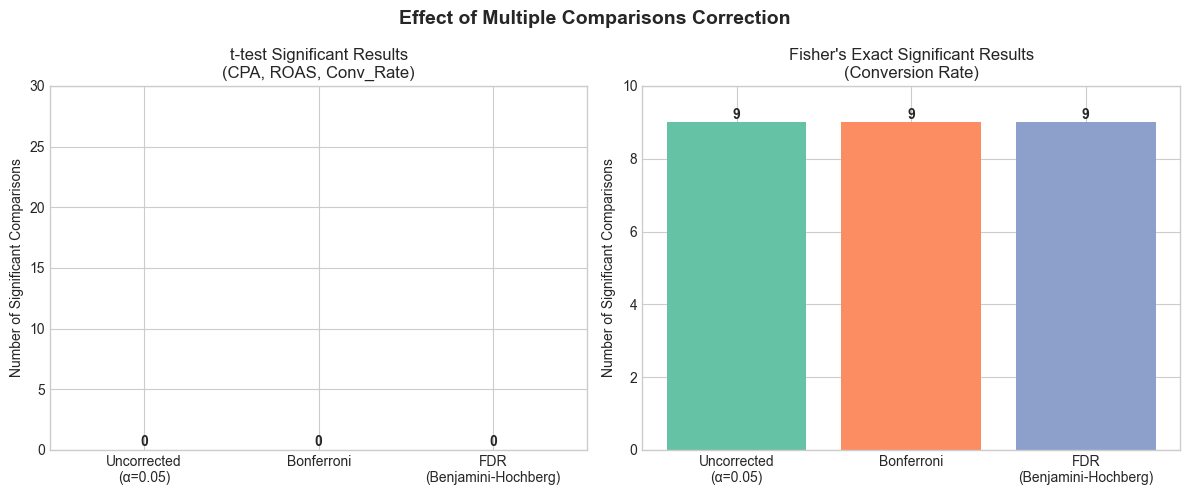

✓ Saved: correction_comparison.png


In [11]:
## Compare All Correction Methods - Summary table and visualization comparing uncorrected, Bonferroni and FDR results.
# Summary comparison table
print("CORRECTION METHODS COMPARISON")
print("="*60)
print(f"\n  {'Method':<25} {'t-test Significant':>20} {'Fisher Significant':>20}")
print(f"  {'-'*65}")
print(f"  {'Uncorrected (α=0.05)':<25} {results_df['Significant'].sum():>20} {fisher_df['Significant'].sum():>20}")
print(f"  {'Bonferroni':<25} {results_df['Significant_Bonferroni'].sum():>20} {fisher_df['Significant_Bonferroni'].sum():>20}")
print(f"  {'FDR (Benjamini-Hochberg)':<25} {results_df['Significant_FDR'].sum():>20} {fisher_df['Significant_FDR'].sum():>20}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Effect of Multiple Comparisons Correction', 
             fontsize=14, fontweight='bold')

methods = ['Uncorrected\n(α=0.05)', 'Bonferroni', 'FDR\n(Benjamini-Hochberg)']

# t-test results
ttest_counts = [
    results_df['Significant'].sum(),
    results_df['Significant_Bonferroni'].sum(),
    results_df['Significant_FDR'].sum()
]
axes[0].bar(methods, ttest_counts, color=sns.color_palette("Set2", 3))
axes[0].set_title('t-test Significant Results\n(CPA, ROAS, Conv_Rate)')
axes[0].set_ylabel('Number of Significant Comparisons')
axes[0].set_ylim(0, len(results_df))
for i, v in enumerate(ttest_counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Fisher results
fisher_counts = [
    fisher_df['Significant'].sum(),
    fisher_df['Significant_Bonferroni'].sum(),
    fisher_df['Significant_FDR'].sum()
]
axes[1].bar(methods, fisher_counts, color=sns.color_palette("Set2", 3))
axes[1].set_title("Fisher's Exact Significant Results\n(Conversion Rate)")
axes[1].set_ylabel('Number of Significant Comparisons')
axes[1].set_ylim(0, len(fisher_df))
for i, v in enumerate(fisher_counts):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('correction_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: correction_comparison.png")

In [ ]:
## Part 3 Summary - Key Findings

**t-tests (CPA, ROAS, Conversion Rate):**
- 0/30 significant results across ALL correction methods
- Cohen's d values all negligible (< 0.02)
- Conclusion: No meaningful CPA or ROAS differences between channels

**Fisher's Exact Test (Conversion Rate):**
- 9/10 significant results survive ALL correction methods
- However odds ratios range only 0.997 to 1.006 — essentially 1.0
- Conclusion: Statistical significance is an artifact of massive sample 
  size (150M+ clicks), NOT evidence of meaningful channel differences

**Which correction method is appropriate here?**
- Both Bonferroni and FDR agree — confirming robustness of results
- The real issue is not false positives but overpowered sample size
- Business decision: differences are too small to justify budget reallocation

**

## Part 5: Business Recommendations
Bootstrap confidence intervals, composite channel scoring and budget allocation.

In [12]:
# Bootstrap confidence intervals for CPA by channel
def bootstrap_ci(data, n_bootstrap=1000, ci_level=0.95):
    """
    Calculate bootstrap confidence interval for the mean.
    
    Parameters:
        data        : array of values
        n_bootstrap : number of bootstrap samples
        ci_level    : confidence level (default 0.95)
    
    Returns:
        lower, upper bounds of confidence interval
    """
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        means.append(np.mean(sample))
    
    alpha = 1 - ci_level
    lower = np.percentile(means, (alpha/2) * 100)
    upper = np.percentile(means, (1 - alpha/2) * 100)
    return lower, upper

# Calculate CI for each channel
print("95% CONFIDENCE INTERVALS FOR CPA BY CHANNEL")
print("="*60)

ci_results = []
for channel in df['Campaign_Type'].unique():
    data = df[df['Campaign_Type'] == channel]['CPA'].dropna().values
    lower, upper = bootstrap_ci(data)
    mean_cpa = data.mean()
    
    ci_results.append({
        'Channel'  : channel,
        'Mean_CPA' : round(mean_cpa, 4),
        'CI_Lower' : round(lower, 4),
        'CI_Upper' : round(upper, 4)
    })
    print(f"  {channel:<15} Mean: ${mean_cpa:.4f}  "
          f"95% CI: [${lower:.4f}, ${upper:.4f}]")

ci_df = pd.DataFrame(ci_results)

95% CONFIDENCE INTERVALS FOR CPA BY CHANNEL
  Social Media    Mean: $2.0539  95% CI: [$1.9473, $2.1566]
  Paid Ads        Mean: $2.0244  95% CI: [$1.9088, $2.1394]
  Influencer      Mean: $2.1048  95% CI: [$2.0041, $2.2209]
  Email           Mean: $2.1110  95% CI: [$2.0000, $2.2310]
  SEO             Mean: $2.0863  95% CI: [$1.9915, $2.1851]


In [13]:
## Step 8.1: Summary of Statistically Significant Findings - Compile all significant findings using FDR-corrected results.
sig_ttest  = results_df[results_df['Significant_FDR'] == True]
sig_fisher = fisher_df[fisher_df['Significant_FDR'] == True]

print("STATISTICALLY SIGNIFICANT FINDINGS (FDR CORRECTED)")
print("="*60)

print(f"\nCPA DIFFERENCES (t-test):")
if len(sig_ttest[sig_ttest['Metric']=='CPA']) == 0:
    print("  None — no significant CPA differences found after FDR correction")
else:
    for _, row in sig_ttest[sig_ttest['Metric']=='CPA'].iterrows():
        better = row['Group_A'] if row['Mean_A'] < row['Mean_B'] else row['Group_B']
        diff   = abs(row['Difference'])
        print(f"  {row['Group_A']} vs {row['Group_B']}")
        print(f"    Lower CPA : {better}")
        print(f"    Difference: ${diff:.4f}  p={row['P_Value_FDR']:.4f}  Cohen's d={row['Cohens_d']:.4f}")

print(f"\nCONVERSION RATE DIFFERENCES (Fisher's exact):")
if len(sig_fisher) == 0:
    print("  None")
else:
    for _, row in sig_fisher.iterrows():
        better = row['Channel_A'] if row['Rate_A'] > row['Rate_B'] else row['Channel_B']
        diff   = abs(row['Difference'])
        print(f"  {row['Channel_A']} vs {row['Channel_B']}")
        print(f"    Higher rate : {better}")
        print(f"    Difference  : {diff:.6f} ({abs(row['Pct_Diff']):.4f}%)")
        print(f"    Odds Ratio  : {row['Odds_Ratio']:.4f}  p={row['P_Value_FDR']:.6f}")

print(f"\nSUMMARY:")
print(f"  Significant CPA differences        : {len(sig_ttest[sig_ttest['Metric']=='CPA'])}")
print(f"  Significant conversion differences : {len(sig_fisher)}")
print(f"  Practical significance             : None — all effect sizes negligible")

STATISTICALLY SIGNIFICANT FINDINGS (FDR CORRECTED)

CPA DIFFERENCES (t-test):
  None — no significant CPA differences found after FDR correction

CONVERSION RATE DIFFERENCES (Fisher's exact):
  Email vs Influencer
    Higher rate : Email
    Difference  : 0.001000 (0.4539%)
    Odds Ratio  : 1.0058  p=0.000000
  Email vs Paid Ads
    Higher rate : Email
    Difference  : 0.000500 (0.2270%)
    Odds Ratio  : 1.0028  p=0.000000
  Email vs SEO
    Higher rate : Email
    Difference  : 0.000500 (0.2270%)
    Odds Ratio  : 1.0031  p=0.000000
  Email vs Social Media
    Higher rate : Email
    Difference  : 0.000600 (0.2724%)
    Odds Ratio  : 1.0039  p=0.000000
  Influencer vs Paid Ads
    Higher rate : Paid Ads
    Difference  : 0.000500 (0.2280%)
    Odds Ratio  : 0.9970  p=0.000000
  Influencer vs SEO
    Higher rate : SEO
    Difference  : 0.000500 (0.2280%)
    Odds Ratio  : 0.9973  p=0.000000
  Influencer vs Social Media
    Higher rate : Social Media
    Difference  : 0.000400 (0.182

In [15]:
##Step 8.3: Composite Channel Scoring & Budget Allocation - Rank channels by multiple metrics and allocate $500K budget proportionally.
# Build composite score from CPA, ROAS and Conv_Rate
# Rank each metric CORRECTLY
# CPA: ascending=True means rank 1 = lowest CPA = BEST
# ROAS: ascending=False means rank 1 = highest ROAS = BEST  
# Conv_Rate: ascending=False means rank 1 = highest rate = BEST

channel_scores['Rank_CPA']       = channel_scores['Mean_CPA'].rank(ascending=True)
channel_scores['Rank_ROAS']      = channel_scores['Mean_ROAS'].rank(ascending=False)
channel_scores['Rank_Conv_Rate'] = channel_scores['Mean_Conv_Rate'].rank(ascending=False)

# Composite score — equal weighting
# NOTE: Lower composite score = BETTER (sum of ranks where 1=best)
channel_scores['Composite_Score'] = (
    channel_scores['Rank_CPA'] * 0.40 +
    channel_scores['Rank_ROAS'] * 0.40 +
    channel_scores['Rank_Conv_Rate'] * 0.20
)

# Sort ASCENDING — lower score = better rank
channel_scores = channel_scores.sort_values('Composite_Score', ascending=True)

print("COMPOSITE CHANNEL RANKING (lower score = better)")
print("="*60)
print(channel_scores[['Channel','Mean_CPA','Mean_ROAS','Mean_Conv_Rate',
                       'Composite_Score']].round(4).to_string(index=False))

# Budget allocation — inverse of composite score (better rank = more budget)
total_budget = 500000
min_allocation = 0.10
max_allocation = 0.30

# Invert score so better channels get more budget
channel_scores['Inv_Score'] = 1 / channel_scores['Composite_Score']
total_inv = channel_scores['Inv_Score'].sum()
channel_scores['Allocation_Pct'] = channel_scores['Inv_Score'] / total_inv

# Apply constraints
channel_scores['Allocation_Pct'] = channel_scores['Allocation_Pct'].clip(
    min_allocation, max_allocation)

# Renormalize
channel_scores['Allocation_Pct'] = (channel_scores['Allocation_Pct'] / 
                                     channel_scores['Allocation_Pct'].sum())

channel_scores['Allocation_$'] = (channel_scores['Allocation_Pct'] * total_budget).round(0)

print(f"\nBUDGET ALLOCATION RECOMMENDATIONS ($500K monthly)")
print("="*60)
print(f"\n  {'Channel':<15} {'Score':>8} {'Allocation':>12} {'Budget ($)':>12}")
print(f"  {'-'*50}")
for _, row in channel_scores.iterrows():
    print(f"  {row['Channel']:<15} {row['Composite_Score']:>8.3f} "
          f"{row['Allocation_Pct']*100:>11.1f}% "
          f"${row['Allocation_$']:>10,.0f}")
print(f"  {'-'*50}")
print(f"  {'TOTAL':<15} {'':>8} {'100.0%':>12} ${total_budget:>10,.0f}")

COMPOSITE CHANNEL RANKING (lower score = better)
     Channel  Mean_CPA  Mean_ROAS  Mean_Conv_Rate  Composite_Score
    Paid Ads    2.0244  6487.0856          0.2195              1.8
Social Media    2.0539  6532.0382          0.2187              2.2
         SEO    2.0863  6377.9943          0.2200              3.2
       Email    2.1110  6479.4829          0.2200              3.4
  Influencer    2.1048  6319.4449          0.2191              4.4

BUDGET ALLOCATION RECOMMENDATIONS ($500K monthly)

  Channel            Score   Allocation   Budget ($)
  --------------------------------------------------
  Paid Ads           1.800        30.0% $   150,192
  Social Media       2.200        24.7% $   123,408
  SEO                3.200        17.0% $    84,843
  Email              3.400        16.0% $    79,852
  Influencer         4.400        12.3% $    61,704
  --------------------------------------------------
  TOTAL                          100.0% $   500,000
